In [120]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import time

import astropy.units as u
import astropy.cosmology.units as cu
import astropy.constants as const

import raytrace

rng = np.random.default_rng()

colors = ['red', 'orangered','yellowgreen', 'royalblue', 'blueviolet']
cm_kpc = u.cm.to(u.kpc)
cm_kpc


with h5py.File("outputs/tng_cluster_catalog.hdf5", "a") as f:
    print(f['table'].keys())
    halo_ids = f['table/haloID'][:]
    halo_pos = f['table/GroupPos'][:] - f['table/GroupCM'][:]
    # print(ids)
    for weight in ('mstar', 'sfr'):
        trace = f[f'trace_{weight}']
        dm_far_mean = f.require_dataset(f'table/dm_{weight}_far_mean', shape=halo_ids.shape, dtype='f8')
        dm_far_std = f.require_dataset(f'table/dm_{weight}_far_std', shape=halo_ids.shape, dtype='f8')
        dm_far_aligned_mean = f.require_dataset(f'table/dm_{weight}_far_aligned_mean', shape=halo_ids.shape, dtype='f8')
        dm_far_aligned_std = f.require_dataset(f'table/dm_{weight}_far_aligned_std', shape=halo_ids.shape, dtype='f8')
    
        # print(f['subhalos'].keys())
        # print(f['table'].keys())
        # print(trace['halo_10293151'].keys())
        for (i, halo_id) in enumerate(halo_ids):
            path = f'halo_{halo_id}'
            
            if path not in trace: 
                dm_far_mean[i] = np.nan
                dm_far_std[i] = np.nan
                dm_far_aligned_mean[i] = np.nan
                dm_far_aligned_std[i] = np.nan
                continue
                
            print(trace[f'halo_{halo_id}'])

            cosine = (lambda a, b: np.sum(a*b, axis=1) / np.linalg.norm(a, axis=1) / np.linalg.norm(b, axis=1))(
                trace[path]['star_pos'][:] - halo_pos[i], trace[path]['direction'][:]
            )

            dm = trace[path]['dm_voronoi']
            dm_near = dm[:, -1,  1] * (cm_kpc**3) * 1000
            dm_far  = dm[:, -1, -1] * (cm_kpc**3) * 1000 - dm_near
    
            dm_far_mean[i] = np.mean(dm_far)
            dm_far_std[i] = np.std(dm_far)
            
            dm_far_aligned_mean[i] = np.mean(dm_far[cosine > 0.9])
            dm_far_aligned_std[i] = np.std(dm_far[cosine > 0.9])
    
        # print(dm_far_mean[:])

<KeysViewHDF5 ['Bmag_uG_10kpc', 'GroupBHMass', 'GroupBHMdot', 'GroupCM', 'GroupContaminationFracByMass', 'GroupContaminationFracByNumPart', 'GroupFirstSub', 'GroupGasMetalFractions', 'GroupGasMetallicity', 'GroupLen', 'GroupLenType', 'GroupMass', 'GroupMassType', 'GroupNsubs', 'GroupOffsetType', 'GroupOrigHaloID', 'GroupPos', 'GroupPrimaryZoomTarget', 'GroupSFR', 'GroupStarMetalFractions', 'GroupStarMetallicity', 'GroupVel', 'GroupWindMass', 'Group_Fe_Crit200', 'Group_Fe_Crit500', 'Group_Fgas_Crit200', 'Group_Fgas_Crit500', 'Group_Fgas_Crit500_max', 'Group_M_Crit200', 'Group_M_Crit500', 'Group_M_Mean200', 'Group_M_TopHat200', 'Group_R_Crit200', 'Group_R_Crit500', 'Group_R_Mean200', 'Group_R_TopHat200', 'Header', 'InfoID', 'InfoType', 'SimulationName', 'SnapshotNumber', 'TracerLengthType', 'TracerOffsetType', 'coolcore_C_phys', 'coolcore_C_scaled', 'coolcore_entropy', 'coolcore_flag', 'coolcore_ne', 'coolcore_ne_slope', 'coolcore_tcool', 'dm_mstar_far_aligned_mean', 'dm_mstar_far_aligne

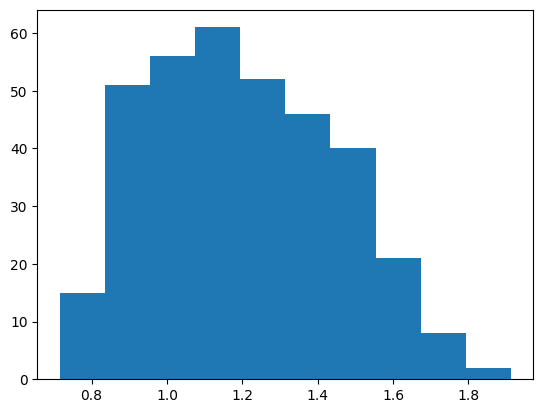

In [73]:
with h5py.File("outputs/tng_cluster_catalog.hdf5", "r") as f:
    plt.hist(f['table/r500c'])

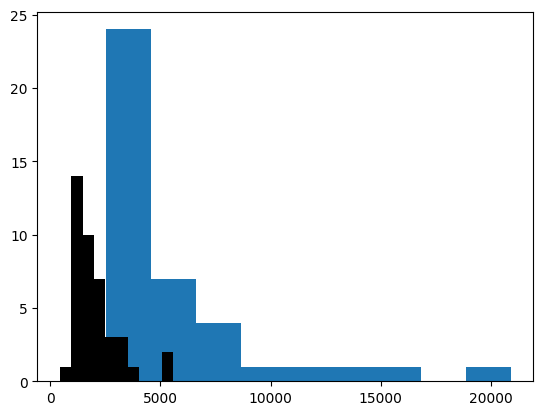

In [83]:
with h5py.File("outputs/tng_cluster_catalog.hdf5", "r") as f:
    plt.hist(f['table/dm_mstar_far_aligned_mean'])
    plt.hist(f['table/dm_mstar_far_mean'], color='black')

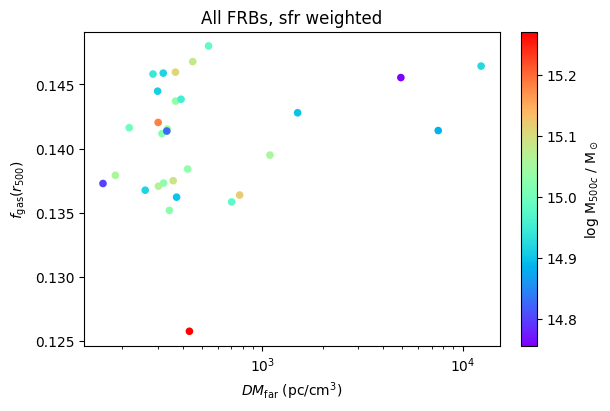

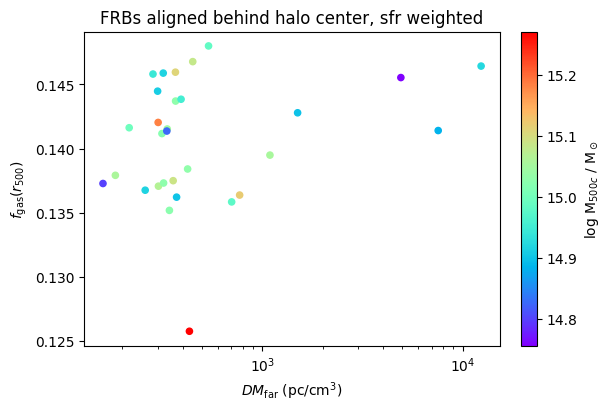

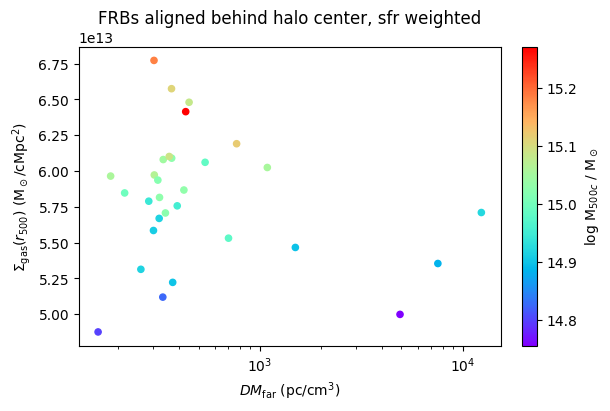

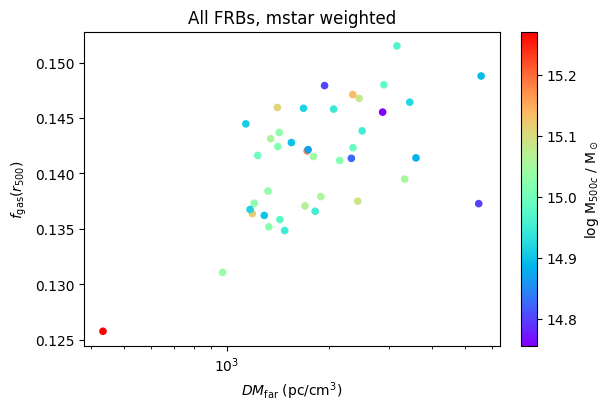

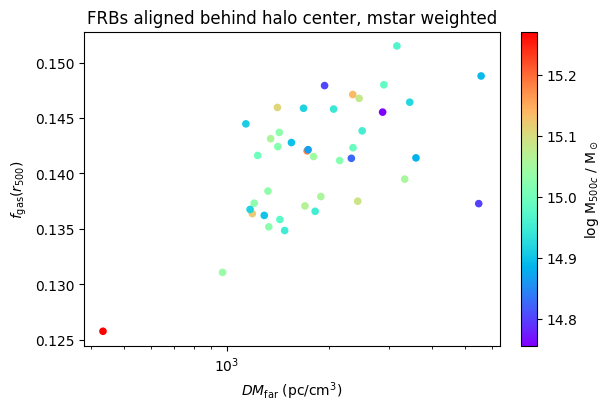

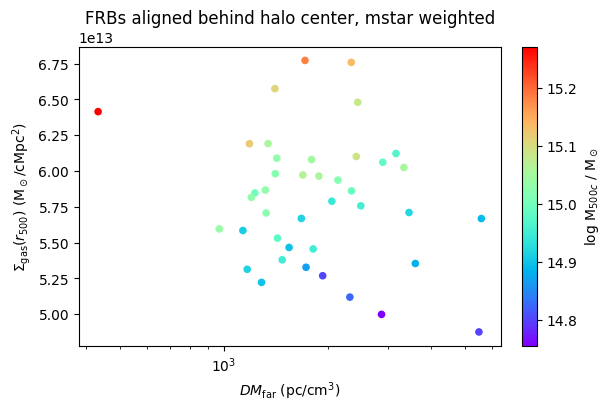

In [121]:
with h5py.File("outputs/tng_cluster_catalog.hdf5", "r") as f:
    for weight in ('sfr', 'mstar'):
        plt.figure(figsize=(6,4), constrained_layout=True)
        # print(f['table'].keys())
    
        x = f[f'table/dm_{weight}_far_mean'][:]      # x-axis
        y = f['table/fgas_r500'][:] # y-axis
        c = f['table/mhalo_500c'][:]             # color by mass (m500c)
    
        mask = (x > 0) & (y > 0)
        sc = plt.scatter(x[mask], y[mask], c=c[mask], s=20, cmap='rainbow')
    
        plt.xscale('log')
        plt.colorbar(sc, label='log M$_{500c}$ / M$_\odot$')
        plt.xlabel(r'$DM_{\rm far}$ (pc/cm$^3$)')
        plt.ylabel(r'$f_{\rm gas}(r_{500})$')
        plt.title(f'All FRBs, {weight} weighted')
        plt.show()
    
        plt.figure(figsize=(6,4), constrained_layout=True)
        x = f[f'table/dm_{weight}_far_mean'][:]      # x-axis
        y = f['table/fgas_r500'][:] # y-axis
        c = f['table/mhalo_500c'][:]             # color by mass (m500c)
    
        mask = (x > 0) & (y > 0)
        sc = plt.scatter(x[mask], y[mask], c=c[mask], s=20, cmap='rainbow')
    
        plt.xscale('log')
        plt.colorbar(sc, label='log M$_{500c}$ / M$_\odot$')
        plt.xlabel(r'$DM_{\rm far}$ (pc/cm$^3$)')
        plt.ylabel(r'$f_{\rm gas}(r_{500})$')
        plt.title(f'FRBs aligned behind halo center, {weight} weighted')
        plt.show()

        plt.figure(figsize=(6,4), constrained_layout=True)
        x = f[f'table/dm_{weight}_far_mean'][:]      # x-axis
        y = f['table/fgas_r500'][:] * (10**f['table/mhalo_500c'][:]) / (f['table/r500c'][:]**2) # y-axis
        c = f['table/mhalo_500c'][:]             # color by mass (m500c)
    
        mask = (x > 0) & (y > 0)
        sc = plt.scatter(x[mask], y[mask], c=c[mask], s=20, cmap='rainbow')
    
        plt.xscale('log')
        plt.colorbar(sc, label='log M$_{500c}$ / M$_\odot$')
        plt.xlabel(r'$DM_{\rm far}$ (pc/cm$^3$)')
        plt.ylabel(r'$\Sigma_{\rm gas}(r_{500})$ (M$_\odot$/cMpc$^2$)')
        plt.title(f'FRBs aligned behind halo center, {weight} weighted')
        plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import time

import astropy.units as u
import astropy.cosmology.units as cu
import astropy.constants as const

import raytrace

rng = np.random.default_rng()

colors = ['red', 'orangered','yellowgreen', 'royalblue', 'blueviolet']
cm_kpc = u.cm.to(u.kpc)
cm_kpc

with h5py.File("outputs/tng_cluster_catalog.hdf5", "r") as f:
    print(f.keys())
    print(f['table'].keys())
    group_sfr = list()
    sub0_relax_dist = list()
    sub1_relax_dist = list()
    sub0_relax_mass = list()
    dm_near_mean = list()
    dm_near_std = list()
    dm_far_mean = list()
    dm_far_std = list()
    dm_far_mean200 = list()
    dm_far_mean500 = list()
    halo_mass = list()
    halo_mgas = list()
    halo_mstar = list()
    halo_m200 = list()
    halo_m500 = list()
    halo_r200 = list()
    halo_r500 = list()
    halo_fe200 = list()
    halo_fe500 = list()
    halo_fgas200 = list()
    halo_fgas500 = list()
    com_impact_dm_far = list()
    dm_far_com_impact = list()
    dm_far_aligned_mean = list()
    dm_far_aligned_std = list()
    com_impact_std = list()
    com_impact_aligned_std = list()
    good_halo_ids = list()

    for halo_id in halo_ids:
        halo = f['halo_' + str(halo_id)]    
        if 'trace' not in halo:
            continue
        if 'Group_Fgas_Crit500' not in halo:
            continue

        good_halo_ids.append(halo_id)

        halo_mass.append(np.sum(halo['GroupMassType'][:]))
        halo_mgas.append(np.sum(halo['GroupMassType'][0]))
        halo_mstar.append(np.sum(halo['GroupMassType'][4]))
        halo_r500.append(halo['Group_R_Crit500'][()])
        halo_r200.append(halo['Group_R_Crit200'][()])
        halo_fgas500.append(halo['Group_Fgas_Crit500'][()])
        halo_fgas200.append(halo['Group_Fgas_Crit200'][()])
        halo_fe500.append(halo['Group_Fe_Crit500'][()])
        halo_fe200.append(halo['Group_Fe_Crit200'][()])
        halo_m500.append(halo['Group_M_Crit500'][()])
        halo_m200.append(halo['Group_M_Crit200'][()])
        subs = halo['subhalos']
        com = halo['GroupCM'][:]
        halo_pos = halo['GroupPos'][:] - com
    
        # central subhalo relaxation
        # print(subs.keys())
        # break
        sub0_cm = np.array([ subs['cm_x'][0], subs['cm_y'][0], subs['cm_z'][0] ]).T - com
        sub1_cm = np.array([ subs['cm_x'][1], subs['cm_y'][1], subs['cm_z'][1] ]).T - com
        sub0_relax_dist.append(np.linalg.norm(sub0_cm) / halo_r200[-1])
        sub1_relax_dist.append(np.linalg.norm(sub1_cm) / halo_r200[-1])
        sub0_relax_mass.append(subs['mass'][0] / halo_mass[-1])
        group_sfr.append(halo['GroupSFR'][()])

        trace = halo['trace']
        # print('\n'.join(list(subs.keys())))
        com_impact = np.linalg.norm(np.cross(trace['star_pos'], trace['direction'], axis=1), axis=-1)
        halo_pos_impact = np.linalg.norm(np.cross(trace['star_pos'] - halo_pos, trace['direction'], axis=1), axis=-1)
        dot = (
            np.sum((trace['star_pos'][:] - halo_pos) * trace['direction'][:], axis=1)
        / np.linalg.norm((trace['star_pos'][:] - halo_pos), axis=1)
        / np.linalg.norm(trace['direction'][:], axis=1)
        )
        
        dm_near = trace['dm_voronoi'][:, -1, 1] * (cm_kpc**3) * 1000
        dm_far = (trace['dm_voronoi'][:, -1, -1] * (cm_kpc**3) * 1000) - dm_near

        dm_near_mean.append(np.mean(dm_near))
        dm_near_std.append(np.std(dm_near))

        dm_far_mean200.append(np.mean(dm_far[com_impact < halo_r200[-1]]))
        dm_far_mean500.append(np.mean(dm_far[(halo_pos_impact < halo_r500[-1]) & (dot < -0.5)]))
        
        com_impact_dm_far.append((np.sum(dm_far*com_impact)/np.sum(dm_far)))
        com_impact_std.append(np.mean(com_impact))
        com_impact_aligned_std.append(np.mean(com_impact[dot > 0.95]))
        dm_far_com_impact.append((np.sum(dm_far*com_impact)/np.sum(com_impact)))

        dm_far_aligned_mean.append(np.mean(dm_far[dot < -0.8]))
        dm_far_aligned_std.append(np.std(dm_far[dot > 0.95]))

        dm_far_mean.append(np.mean(dm_far))
        dm_far_std.append(np.std(dm_far))
        # plt.scatter(trace['star_pos'][:, 0], trace['star_pos'][:, 1])
    # print(impact.shape, dm.shape)
good_halo_ids = np.array(good_halo_ids)
group_sfr = np.array(group_sfr)
sub0_relax_dist = np.array(sub0_relax_dist)
sub1_relax_dist = np.array(sub1_relax_dist)
sub0_relax_mass = np.array(sub0_relax_mass)
dm_near_mean = np.array(dm_near_mean)
dm_near_std = np.array(dm_near_std)
dm_far_mean = np.array(dm_far_mean)
dm_far_std = np.array(dm_far_std)
dm_far_mean200 = np.array(dm_far_mean200)
dm_far_mean500 = np.array(dm_far_mean500)
halo_mass = np.array(halo_mass)
halo_mgas = np.array(halo_mgas)
halo_mstar = np.array(halo_mstar)
halo_m200 = np.array(halo_m200)
halo_m500 = np.array(halo_m500)
halo_r200 = np.array(halo_r200)
halo_r500 = np.array(halo_r500)
halo_fgas200 = np.array(halo_fgas200)
halo_fgas500 = np.array(halo_fgas500)
halo_fe200 = np.array(halo_fe200)
halo_fe500 = np.array(halo_fe500)
com_impact_dm_far = np.array(com_impact_dm_far)
com_impact_std = np.array(com_impact_std)
com_impact_aligned_std = np.array(com_impact_aligned_std)
dm_far_com_impact = np.array(dm_far_com_impact)
dm_far_aligned_mean = np.array(dm_far_aligned_mean)
dm_far_aligned_std = np.array(dm_far_aligned_std)

<KeysViewHDF5 ['subhalos', 'table', 'trace_mstar', 'trace_sfr']>
<KeysViewHDF5 ['Bmag_uG_10kpc', 'GroupBHMass', 'GroupBHMdot', 'GroupCM', 'GroupContaminationFracByMass', 'GroupContaminationFracByNumPart', 'GroupFirstSub', 'GroupGasMetalFractions', 'GroupGasMetallicity', 'GroupLen', 'GroupLenType', 'GroupMass', 'GroupMassType', 'GroupNsubs', 'GroupOffsetType', 'GroupOrigHaloID', 'GroupPos', 'GroupPrimaryZoomTarget', 'GroupSFR', 'GroupStarMetalFractions', 'GroupStarMetallicity', 'GroupVel', 'GroupWindMass', 'Group_Fe_Crit200', 'Group_Fe_Crit500', 'Group_Fgas_Crit200', 'Group_Fgas_Crit500', 'Group_Fgas_Crit500_max', 'Group_M_Crit200', 'Group_M_Crit500', 'Group_M_Mean200', 'Group_M_TopHat200', 'Group_R_Crit200', 'Group_R_Crit500', 'Group_R_Mean200', 'Group_R_TopHat200', 'Header', 'InfoID', 'InfoType', 'SimulationName', 'SnapshotNumber', 'TracerLengthType', 'TracerOffsetType', 'coolcore_C_phys', 'coolcore_C_scaled', 'coolcore_entropy', 'coolcore_flag', 'coolcore_ne', 'coolcore_ne_slope', 'c

NameError: name 'halo_ids' is not defined

# gas fraction

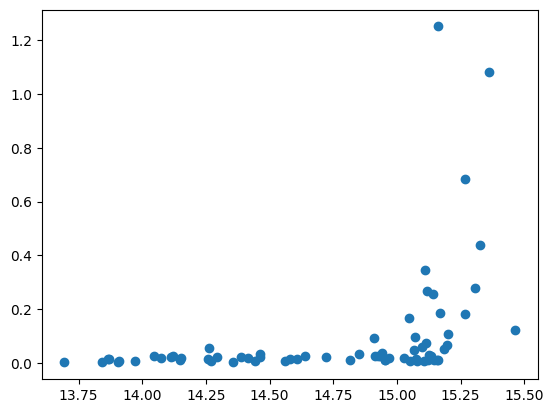

In [65]:
plt.scatter(np.log10(halo_mass)+10, sub0_relax_dist)

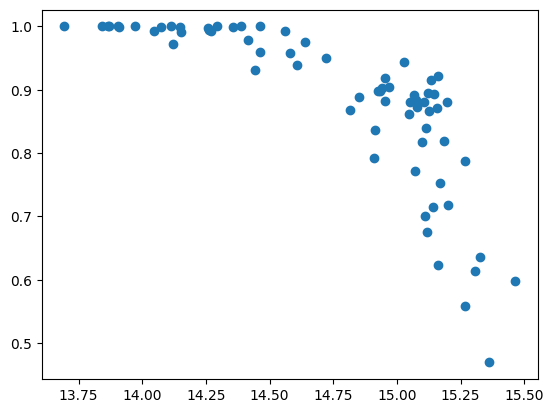

In [66]:
plt.scatter(np.log10(halo_mass)+10, halo_fgas200*halo_m200/halo_mgas)

In [67]:
good_halo_ids[halo_fgas500<0.04]

array([ 1263675, 17469184, 18083789,  6748570])

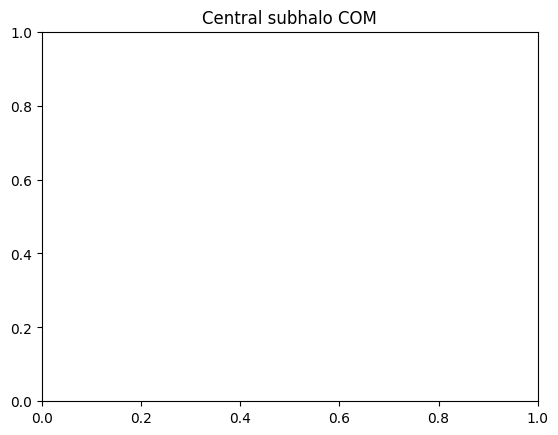

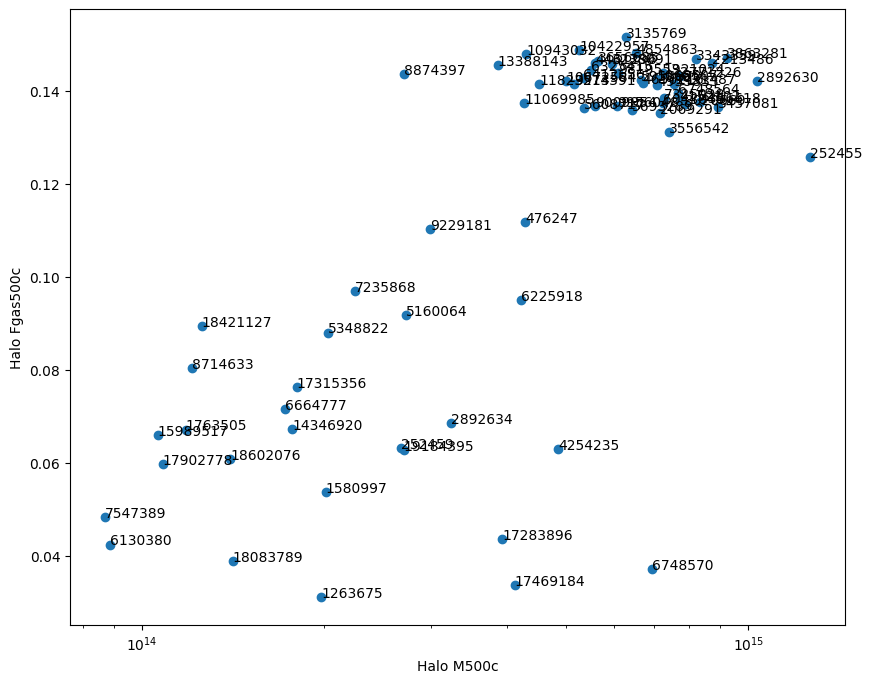

In [4]:
# plt.scatter(halo_mass, halo_fgas200)
plt.title('Central subhalo COM')
xs = 1e10*halo_m500
plt.figure(figsize=(10,8))
ys = halo_fgas500
plt.scatter(xs, ys)
for (j,x,y) in zip(good_halo_ids,xs,ys):
    plt.text(x,y,j)

plt.xlabel('Halo M500c')
plt.ylabel('Halo Fgas500c')
plt.semilogx()
plt.savefig('fgas500.png')

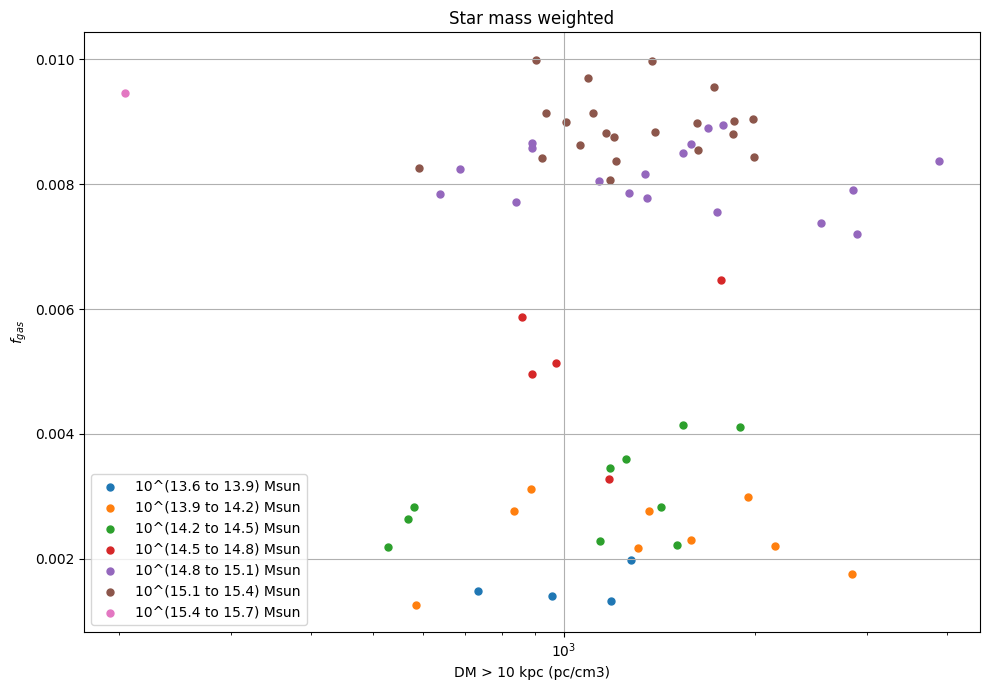

In [8]:
plt.figure(figsize=(10,7))
mrange = np.arange(0, 20., 0.3)
for i in range(len(mrange)-1):
    select = (10.**mrange[i] < halo_mass) & (halo_mass < 10.**mrange[i+1])# & (halo_fgas500 > 0.1)
    if np.sum(select) < 1: continue
    xs = dm_far_aligned_mean[select]
    ys = (halo_fgas500*halo_m500/halo_r500/halo_r500)[select]
    # ys = (halo_fgas200*halo_m200/halo_r200/halo_r200)[select]
    # ys = (halo_mgas/halo_r500/halo_r500)[select]
    # ys = halo_fgas500[select]
    # ids = good_halo_ids[select]
    plt.scatter(xs, ys, marker='.', s=100, label=f'10^({10+mrange[i]:.1f} to {10+mrange[i+1]:.1f}) Msun')
    # for (j,x,y) in zip(ids,xs,ys):
    #     plt.text(x,y,j)
# plt.loglog()

plt.semilogx()
plt.legend()
# plt.xlim(1e2,1e4)
# plt.xlim(3e2, 3e4)

plt.grid()
plt.xlabel('DM > 10 kpc (pc/cm3)')
plt.ylabel('$f_{gas}$')
plt.savefig('vis/halo_trends/fgasdiff_dmfar.png')
plt.title('Star mass weighted')
plt.tight_layout()

plt.show()

(array([ 3.,  4., 13., 21.,  8.,  6.,  4.,  5.,  1.,  3.]),
 array([-2.67385153, -2.39674074, -2.11962994, -1.84251915, -1.56540836,
        -1.28829756, -1.01118677, -0.73407597, -0.45696518, -0.17985439,
         0.09725641]),
 <BarContainer object of 10 artists>)

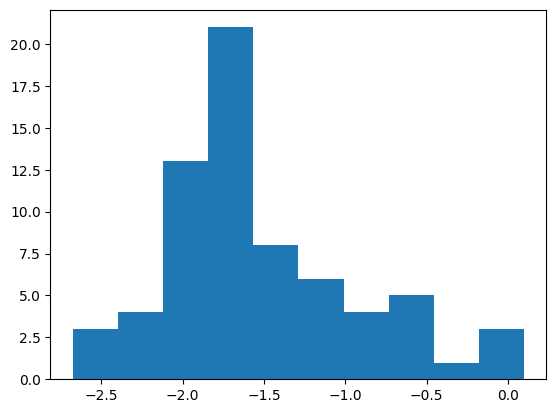

In [9]:
plt.hist(np.log10(sub0_relax_dist))

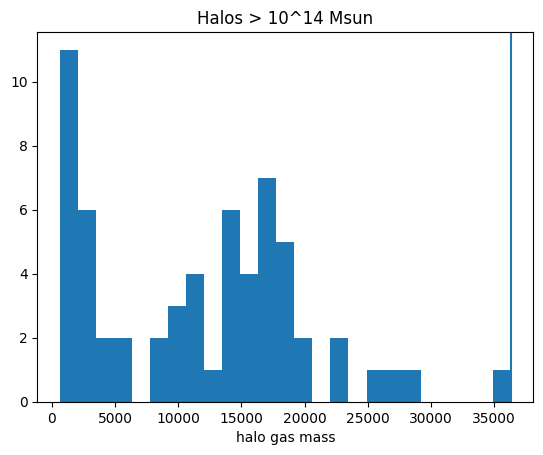

In [93]:
x = (halo_fgas500 * halo_m500)
x = (halo_fgas200 * halo_m200)
x = (halo_mgas)
plt.xlabel('halo gas mass')
plt.title('Halos > 10^14 Msun')
plt.hist(x[halo_mass>1e4], bins=25)
plt.axvline(x[(halo_mass>1e4) & (good_halo_ids==252455)])

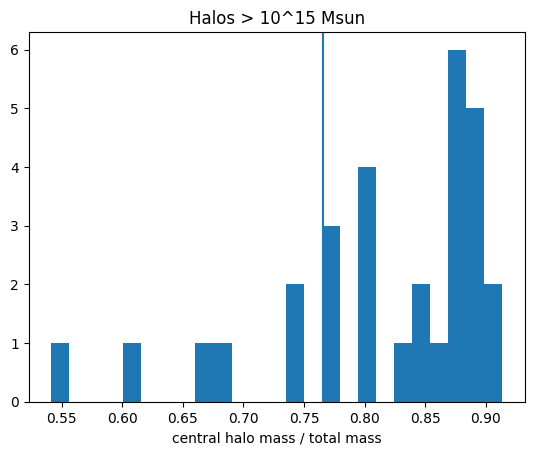

In [94]:
x = (sub0_relax_mass)
plt.xlabel('central halo mass / total mass')
plt.title('Halos > 10^14 Msun')
plt.hist(x[halo_mass>1e4], bins=25)
plt.axvline(x[(halo_mass>1e4) & (good_halo_ids==252455)])

In [7]:
' '.join([('halo_' + str(x) + '.gif') for x in good_halo_ids[halo_mass>1e5]])

'halo_1068507.gif halo_1431487.gif halo_1921024.gif halo_2069291.gif halo_2213486.gif halo_252455.gif halo_2771226.gif halo_2892630.gif halo_3020669.gif halo_3135769.gif halo_3238091.gif halo_3343359.gif halo_3457081.gif halo_3556542.gif halo_3656685.gif halo_3863281.gif halo_4152102.gif halo_4356618.gif halo_4461296.gif halo_4656216.gif halo_4854863.gif halo_4959833.gif halo_5608717.gif halo_5693289.gif halo_5956970.gif halo_6043040.gif halo_6325415.gif halo_6412656.gif halo_6748564.gif halo_7325028.gif'

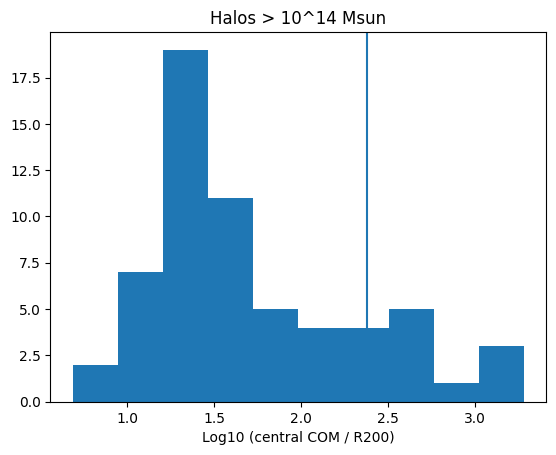

In [95]:
x = np.log10(sub0_relax_dist)
plt.xlabel('Log10 (central COM / R200)')
plt.title('Halos > 10^14 Msun')
plt.hist(x[halo_mass>1e4])
plt.axvline(x[(halo_mass>1e4) & (good_halo_ids==252455)])

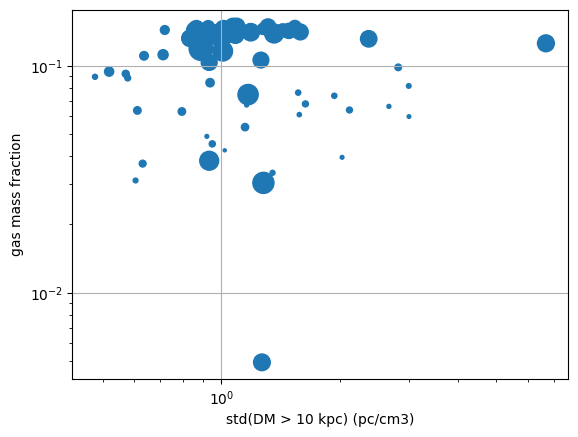

In [6]:
plt.scatter(np.array(dm_far_std)/dm_far_mean, halo_fgas500, s=(np.array(halo_mass))*1e-3)
plt.loglog()
# plt.xlim(1e2,1e4)
plt.grid()
# plt.legend()
plt.xlabel('std(DM > 10 kpc) (pc/cm3)')
plt.ylabel('gas mass fraction')
plt.savefig('vis/halo_trends/fgas_dmstd.png')
plt.show()

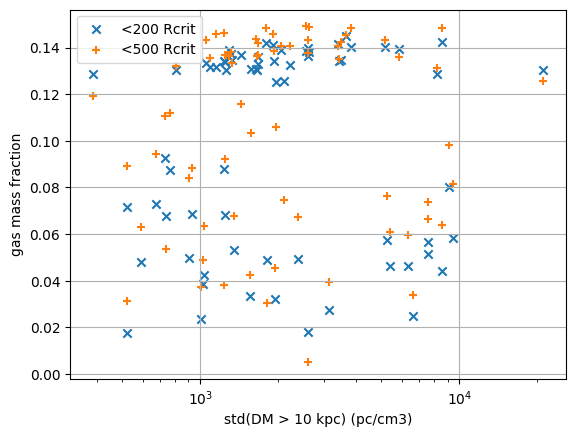

In [7]:
plt.scatter(np.array(dm_far_std), halo_fgas200, label='<200 Rcrit', marker='x')
plt.scatter(np.array(dm_far_std), halo_fgas500, label='<500 Rcrit', marker='+')
plt.semilogx()
# plt.xlim(1e2,1e4)
plt.grid()
plt.legend()
plt.xlabel('std(DM > 10 kpc) (pc/cm3)')
plt.ylabel('gas mass fraction')
plt.savefig('vis/halo_trends/fgas_dmstd.png')
plt.show()

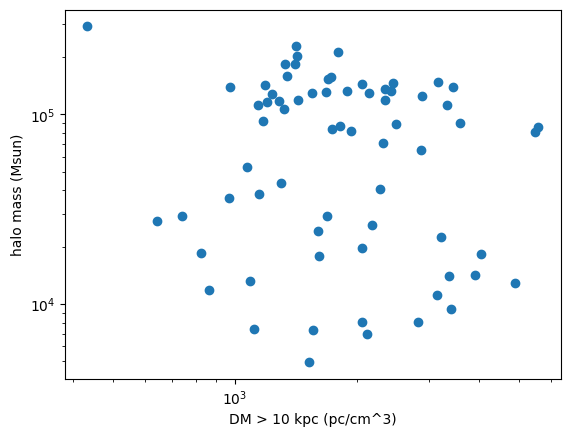

In [8]:
plt.scatter(dm_far_mean, halo_mass)
plt.loglog()
plt.ylabel('halo mass (Msun)')
plt.xlabel('DM > 10 kpc (pc/cm^3)')
plt.show()

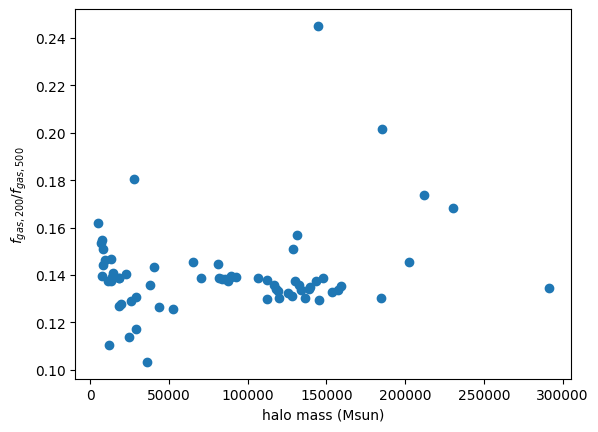

In [9]:
plt.scatter(halo_mass, (np.log10(halo_fgas200/halo_fgas500)+0.7)/np.log10(halo_mass))
plt.xlabel('halo mass (Msun)')
plt.ylabel('$f_{gas,200}/f_{gas,500}$')
plt.show()

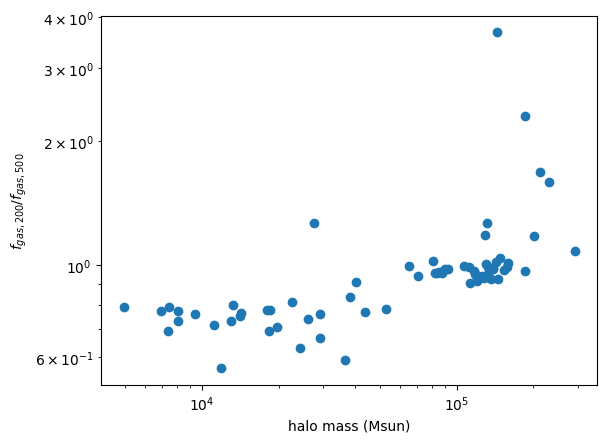

In [10]:
plt.scatter(halo_mass, halo_fgas200/halo_fgas500)
plt.loglog()
plt.xlabel('halo mass (Msun)')
plt.ylabel('$f_{gas,200}/f_{gas,500}$')
plt.show()

In [11]:
len(dm_far_mean)

68

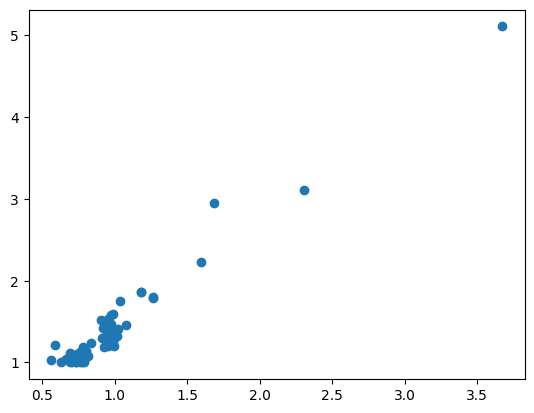

In [12]:
plt.scatter(halo_fgas200/halo_fgas500, halo_m200*halo_fgas200/(halo_m500*halo_fgas500))

/tmp/ipykernel_128520/2112942632.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


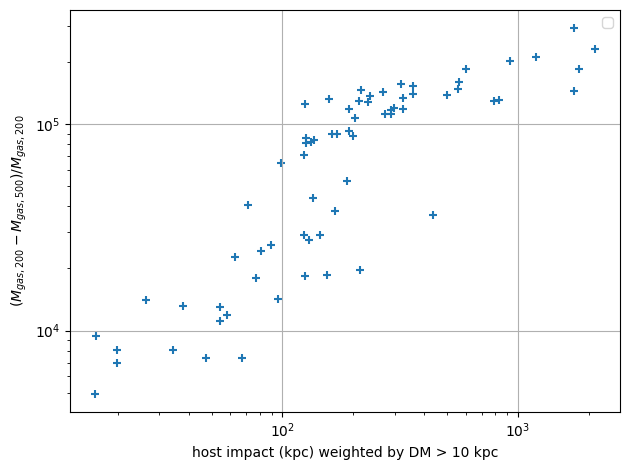

In [13]:
plt.scatter(com_impact_dm_far, halo_mass, marker='+')
plt.loglog()
plt.legend()
# plt.xlim(1e2,1e4)
plt.grid()
plt.xlabel('host impact (kpc) weighted by DM > 10 kpc')
plt.ylabel('$(M_{gas,200} - M_{gas,500})/M_{gas,200}$')
plt.savefig('vis/halo_trends/mgasdiff_dmfar.png')
plt.tight_layout()

plt.show()

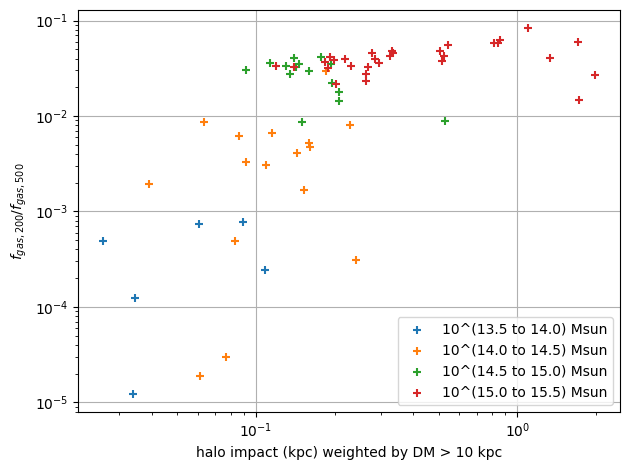

In [14]:
mrange = np.arange(0., 20., 0.5)
for i in range(len(mrange)-1):
    select = (10.**mrange[i] < halo_mass) & (halo_mass < 10.**mrange[i+1])
    if np.sum(select) < 1: continue
    plt.scatter((com_impact_dm_far/halo_r500)[select], ((halo_fgas200*halo_m200-halo_fgas500*halo_m500)/halo_m200)[select], marker='+', label=f'10^({10+mrange[i]} to {10+mrange[i+1]}) Msun')
plt.loglog()
plt.legend()
# plt.xlim(1e2,1e4)
plt.grid()
plt.xlabel('halo impact (kpc) weighted by DM > 10 kpc')
plt.ylabel('$f_{gas,200}/f_{gas,500}$')
plt.savefig('vis/halo_trends/fgasdiff_dmfar.png')
plt.tight_layout()

plt.show()

In [31]:
sub0_relax_dist

array([1036.14841384, 1224.68433978,  534.38233539,  954.12112423,
        413.71242722,  233.13698337, 2677.2449117 ,  522.61596353,
        329.27526987, 1940.3900063 , 1853.04328663, 2932.46325111,
       1990.30711135, 3037.12591028, 4044.8716869 , 2134.55186479,
       3133.39222561, 2990.23393928, 2269.99664199, 3337.68737125,
       2997.00313115,  713.31336759,  521.06080039,  296.72599223,
        392.32726916, 1227.52372341,  842.3972929 ,  395.96703129,
        599.97860529,  651.08911491,  625.05115191, 1146.08915505,
        572.48005817,  630.11773957,  587.15255372,  730.96215305,
       1007.45474829,  908.01837369, 2870.15489151,  841.11221718,
        540.0292125 ,  383.18100601,  710.67492168,  823.52263772,
        821.8609919 , 1886.63252515, 2341.66667913, 1179.35979973,
        933.02570032,  740.27887002, 1000.91323985, 6535.40157178,
       1230.38576692,  822.15877828,  786.74809333, 1852.45948376,
       1200.23399144, 2346.48215192, 1680.68683086,  891.56051

In [ ]:
plt.hist(halo_

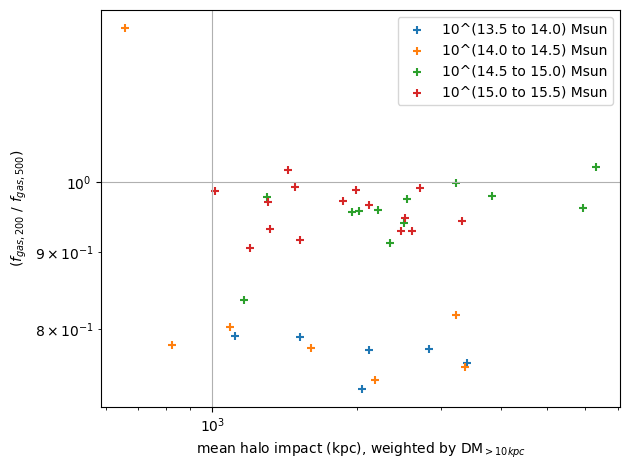

In [2]:
mrange = np.arange(0., 20., 0.5)
for i in range(len(mrange)-1):
    select = (10.**mrange[i] < halo_mass) & (halo_mass < 10.**mrange[i+1]) & (sub0_relax_mass > 0.85)
    if np.sum(select) < 1: continue
    plt.scatter(dm_far_mean200[select], (halo_fgas200/halo_fgas500)[select], marker='+', label=f'10^({10+mrange[i]} to {10+mrange[i+1]}) Msun')
plt.loglog()
plt.legend()
# plt.xlim(1e2,1e4)
plt.grid()
plt.xlabel('mean halo impact (kpc), weighted by DM$_{ > 10 kpc}$')
plt.ylabel('$(f_{gas,200}~/~f_{gas,500})$')
plt.savefig('vis/halo_trends/fgasdiff_dmfar.png')
plt.tight_layout()

plt.show()

(array([ 5., 20., 14., 12.,  4.,  7.,  2.,  1.,  1.,  2.]),
 array([ 432.35085443,  947.54440459, 1462.73795476, 1977.93150493,
        2493.1250551 , 3008.31860527, 3523.51215543, 4038.7057056 ,
        4553.89925577, 5069.09280594, 5584.28635611]),
 <BarContainer object of 10 artists>)

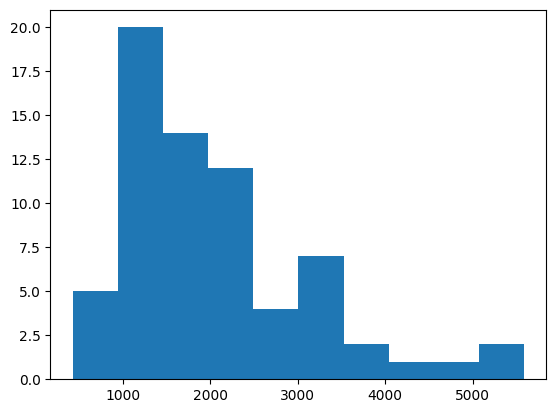

In [42]:
plt.hist(dm_far_mean)

Text(0.5, 0, 'aligned DM / all DM')

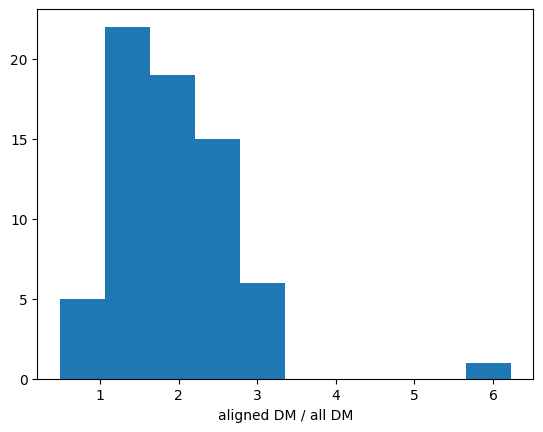

In [90]:
plt.hist(dm_far_aligned/dm_far_mean)
plt.xlabel('aligned DM / all DM')

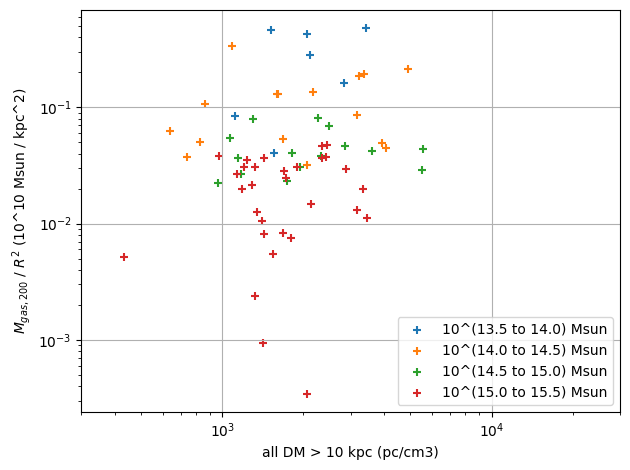

In [33]:
mrange = np.arange(0., 20., 0.5)
for i in range(len(mrange)-1):
    select = (10.**mrange[i] < halo_mass) & (halo_mass < 10.**mrange[i+1])
    if np.sum(select) < 1: continue
    plt.scatter(dm_far_mean[select], (halo_fgas200 * halo_m200 / com_impact_std**2)[select], marker='+', label=f'10^({10+mrange[i]} to {10+mrange[i+1]}) Msun')
plt.loglog()
# plt.semilogx()
plt.legend()
# plt.xlim(1e2,1e4)
plt.grid()
plt.xlabel('all DM > 10 kpc (pc/cm3)')
plt.ylabel('$M_{gas,200}~/~R^2$ (10^10 Msun / kpc^2)')
plt.savefig('vis/halo_trends/fgasdiff_dmfar.png')
plt.xlim(3e2, 3e4)
plt.tight_layout()

plt.show()

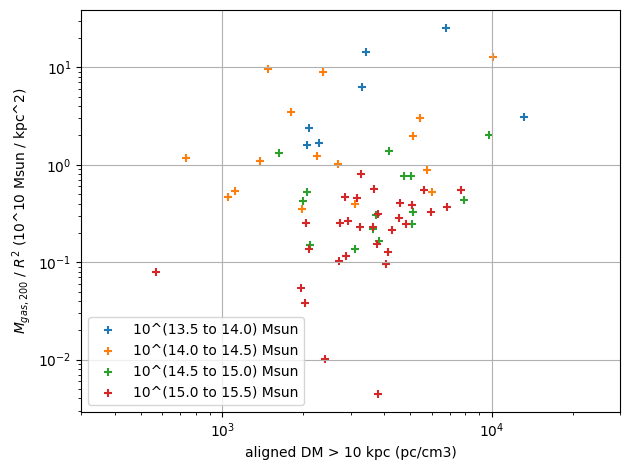

In [29]:
mrange = np.arange(0., 20., 0.5)
for i in range(len(mrange)-1):
    select = (10.**mrange[i] < halo_mass) & (halo_mass < 10.**mrange[i+1])
    if np.sum(select) < 1: continue
    plt.scatter(dm_far_aligned_mean[select], (halo_fgas200 * halo_m200 / com_impact_aligned_std**2)[select], marker='+', label=f'10^({10+mrange[i]} to {10+mrange[i+1]}) Msun')
plt.loglog()
# plt.semilogx()
plt.legend()
# plt.xlim(1e2,1e4)
plt.grid()
plt.xlabel('aligned DM > 10 kpc (pc/cm3)')
plt.ylabel('$M_{gas,200}~/~R^2$ (10^10 Msun / kpc^2)')
plt.savefig('vis/halo_trends/fgasdiff_dmfar.png')
plt.xlim(3e2, 3e4)
plt.tight_layout()

plt.show()

In [9]:
mrange = np.arange(0., 20., 0.5)
for i in range(len(mrange)-1):
    select = (10.**mrange[i] < halo_mass) & (halo_mass < 10.**mrange[i+1])
    if np.sum(select) < 1: continue
    plt.scatter(dm_far_aligned[select], (halo_fgas200)[select], marker='+', label=f'10^({10+mrange[i]} to {10+mrange[i+1]}) Msun')
# plt.loglog()
plt.semilogx()
plt.legend()
# plt.xlim(1e2,1e4)
plt.grid()
plt.xlabel('aligned DM > 10 kpc (pc/cm3)')
plt.ylabel('$f_{gas,200}$')
plt.savefig('vis/halo_trends/fgasdiff_dmfar.png')
plt.xlim(3e2, 3e4)
plt.tight_layout()

plt.show()

NameError: name 'dm_far_aligned' is not defined

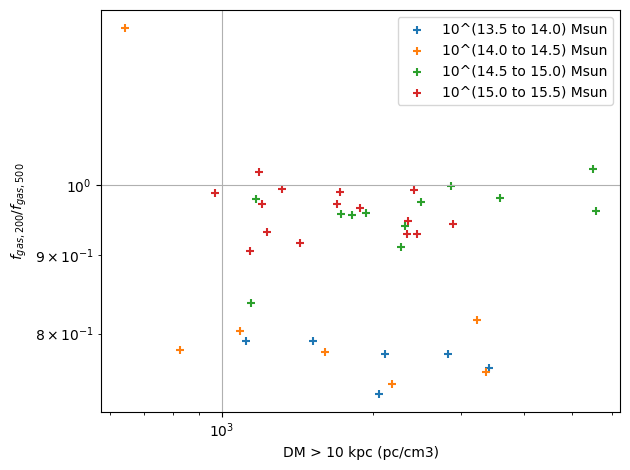

In [25]:
mrange = np.arange(0., 20., 0.5)
for i in range(len(mrange)-1):
    select = (10.**mrange[i] < halo_mass) & (halo_mass < 10.**mrange[i+1]) & (sub0_relax_mass > 0.85)
    if np.sum(select) < 1: continue
    plt.scatter(dm_far_mean[select], (halo_fgas200/halo_fgas500)[select], marker='+', label=f'10^({10+mrange[i]} to {10+mrange[i+1]}) Msun')
plt.loglog()
plt.legend()
# plt.xlim(1e2,1e4)
plt.grid()
plt.xlabel('DM > 10 kpc (pc/cm3)')
plt.ylabel('$f_{gas,200}/f_{gas,500}$')
plt.savefig('vis/halo_trends/fgasdiff_dmfar.png')
plt.tight_layout()

plt.show()

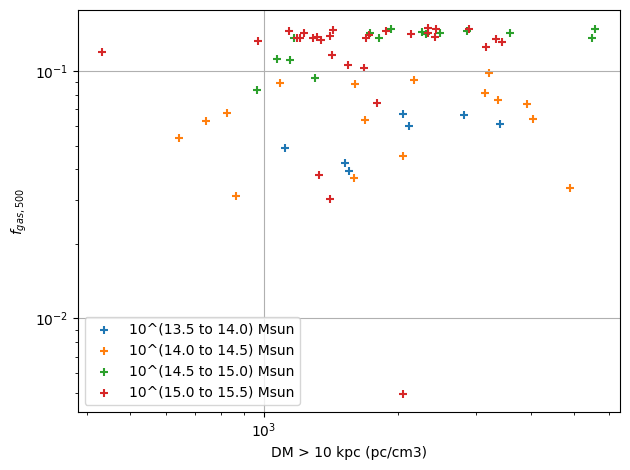

In [18]:
mrange = np.arange(0., 20., 0.5)
for i in range(len(mrange)-1):
    select = (10.**mrange[i] < halo_mass) & (halo_mass < 10.**mrange[i+1])
    if np.sum(select) < 1: continue
    plt.scatter(dm_far_mean[select], (halo_fgas500)[select], marker='+', label=f'10^({10+mrange[i]} to {10+mrange[i+1]}) Msun')
plt.loglog()
plt.legend()
# plt.xlim(1e2,1e4)
plt.grid()
plt.xlabel('DM > 10 kpc (pc/cm3)')
plt.ylabel('$f_{gas,500}$')
plt.savefig('vis/halo_trends/fgas500_dmfar.png')
plt.tight_layout()
plt.show()

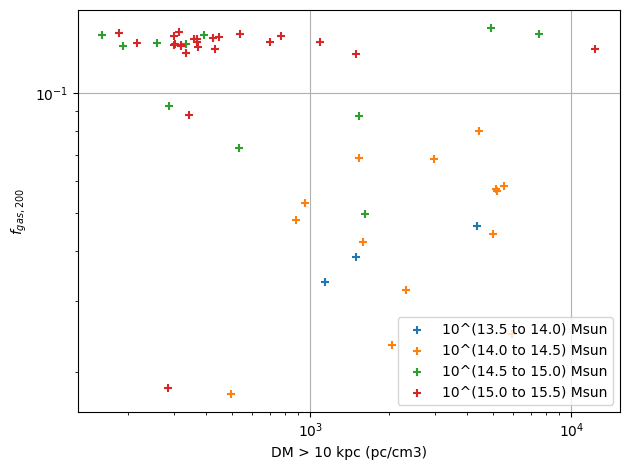

In [160]:
mrange = np.arange(0., 20., 0.5)
for i in range(len(mrange)-1):
    select = (10.**mrange[i] < halo_mass) & (halo_mass < 10.**mrange[i+1])
    if np.sum(select) < 1: continue
    plt.scatter(dm_far_mean[select], (halo_fgas200)[select], marker='+', label=f'10^({10+mrange[i]} to {10+mrange[i+1]}) Msun')
plt.loglog()
plt.legend()
# plt.xlim(1e2,1e4)
plt.grid()
plt.xlabel('DM > 10 kpc (pc/cm3)')
plt.ylabel('$f_{gas,200}$')
plt.savefig('vis/halo_trends/fgas200_dmfar.png')
plt.tight_layout()
plt.show()

In [33]:
mrange = np.arange(0., 20., 0.5)
for i in range(len(mrange)-1):
    select = (10.**mrange[i] < halo_mass) & (halo_mass < 10.**mrange[i+1]) & (dot > 0.95)
    if np.sum(select) < 1: continue
    plt.scatter(dm_far_mean[select], (halo_fgas200)[select], marker='+', label=f'10^({10+mrange[i]} to {10+mrange[i+1]}) Msun')
plt.loglog()
plt.legend()
# plt.xlim(1e2,1e4)
plt.grid()
plt.xlabel('DM > 10 kpc (pc/cm3)')
plt.ylabel('$f_{gas,200}$')
# plt.savefig('vis/halo_trends/fgas200_dmfar.png')
plt.tight_layout()
plt.show()

ValueError: operands could not be broadcast together with shapes (68,) (600,) 

/tmp/ipykernel_37129/838585087.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


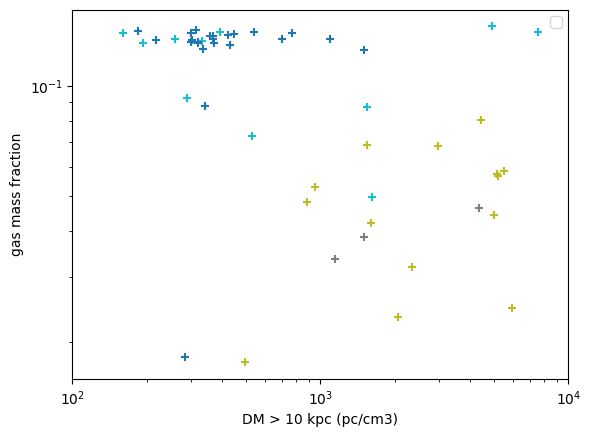

In [141]:
# plt.scatter(np.array(dm_far_mean), halo_fgas200, label='<200 Rcrit', s=(np.array(halo_mass))*1e-3)
# plt.scatter(np.array(dm_far_mean), halo_fgas500, label='<500 Rcrit', s=(np.array(halo_mass))*1e-3)
mrange = np.arange(0., 20., 0.5)
for i in range(len(mrange)-1):
    select = (10.**mrange[i] < halo_mass) & (halo_mass < 10.**mrange[i+1])
    plt.scatter(dm_far_mean[select], halo_fgas200[select], marker='+')

plt.loglog()
plt.xlim(1e2,1e4)
plt.legend()
plt.xlabel('DM > 10 kpc (pc/cm3)')
plt.ylabel('gas mass fraction')
plt.savefig('vis/halo_trends/fgas_dmfar.png')
plt.show()

# Other

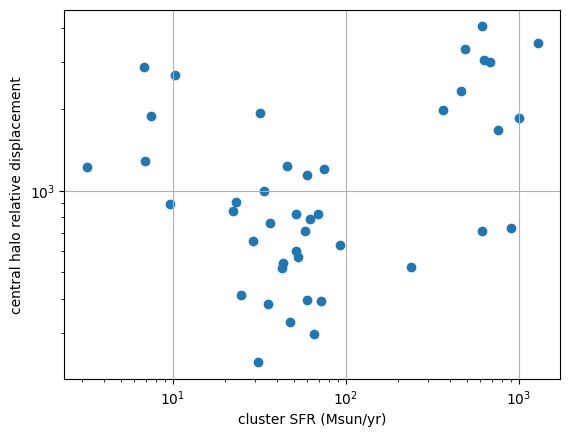

In [36]:
plt.scatter(group_sfr, sub0_relax_dist)
plt.loglog()
plt.xlabel('cluster SFR (Msun/yr)')
plt.ylabel('central halo relative displacement')
plt.grid()

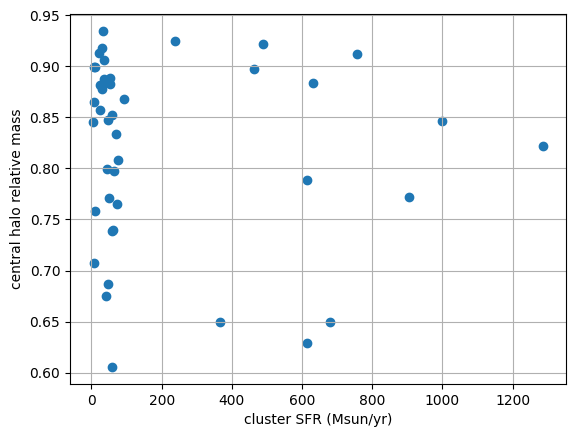

In [37]:
plt.scatter(group_sfr, sub0_relax_mass)
plt.xlabel('cluster SFR (Msun/yr)')
plt.ylabel('central halo relative mass')
plt.grid()

Text(0, 0.5, 'DM < 10 kpc')

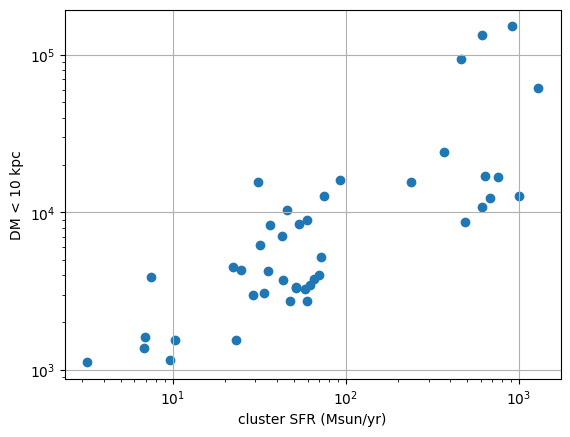

In [38]:
plt.scatter(group_sfr, np.array(dm_near_mean))
plt.xlabel('cluster SFR (Msun/yr)')
plt.loglog()
plt.grid()
plt.ylabel('DM < 10 kpc')

Text(0, 0.5, 'DM > 10 kpc')

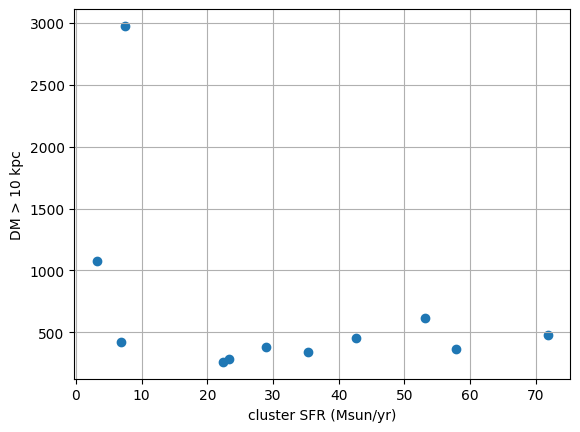

In [9]:
plt.scatter(group_sfr, np.array(dm_far_mean))
plt.xlabel('cluster SFR (Msun/yr)')
plt.grid()
plt.ylabel('DM > 10 kpc')

[]

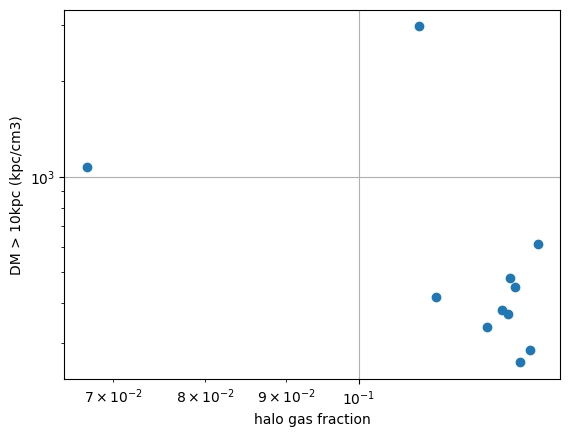

In [20]:
plt.scatter(halo_fgas, np.array(dm_far_mean) * (cm_kpc**3) * 1000)
plt.ylabel('DM > 10kpc (kpc/cm3)')
plt.grid()
plt.xlabel('halo gas fraction')
plt.loglog()

In [37]:
print(group_sfr)
print(halo_ids)

[np.float64(71.83643341064453), np.float64(23.260801315307617), np.float64(22.33913230895996), np.float64(7.512110233306885)]
['252455', '4152102', '4356618', '5160064']


Text(0, 0.5, 'DM < 10 kpc (pc/cm^3)')

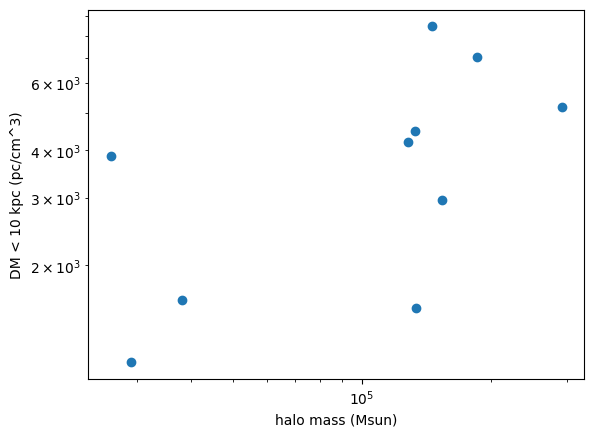

In [34]:
plt.scatter(halo_mass, np.array(dm_near_mean) * (cm_kpc**3) * 1000)
plt.loglog()
plt.xlabel('halo mass (Msun)')
plt.ylabel('DM < 10 kpc (pc/cm^3)')

Text(0, 0.5, 'DM > 10 kpc (pc/cm^3)')

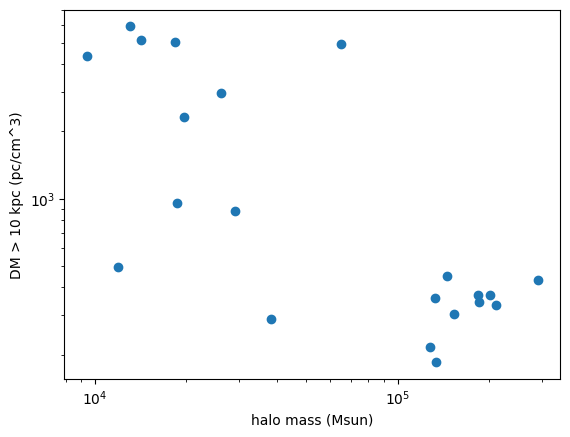

Text(0, 0.5, 'DM > 10 kpc')

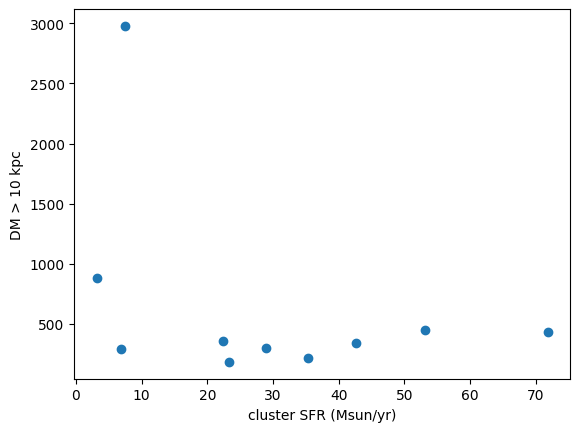

In [31]:
plt.scatter(group_sfr, np.array(dm_far_mean) * (cm_kpc**3) * 1000)
# plt.scatter(group_sfr, (np.array(dm_far_mean) - np.array(dm_far_std)) * (cm_kpc**3) * 1000)
# plt.scatter(group_sfr, (np.array(dm_far_mean) + np.array(dm_far_std)) * (cm_kpc**3) * 1000)
plt.xlabel('cluster SFR (Msun/yr)')
plt.ylabel('DM > 10 kpc')

In [57]:
np.max(star_ssfr)

np.float64(6.8084013982172564e-09)

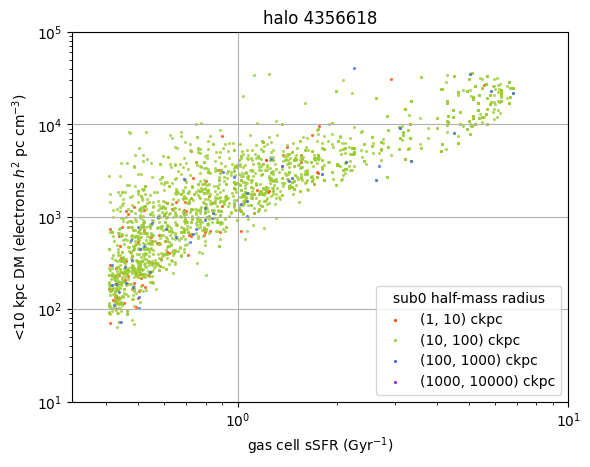

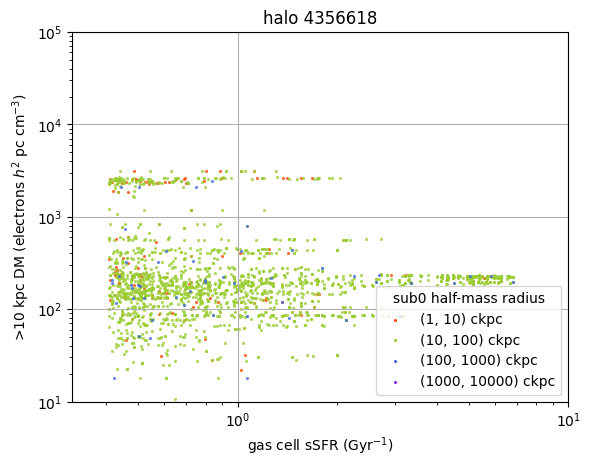

In [58]:
for (j, dm) in enumerate((dm_near, dm_far)):
    plt.title('halo ' + halo_id)
    
    for i in np.arange(1, 5):
        select = (10**(i-1) < sub_rads) & (sub_rads < 10**i)
        plt.scatter(
            star_ssfr[select] * 1e9, 
            dm[select] * (cm_kpc**3) * 1000, 
            s=5, alpha=0.8, lw=0, c=colors[i],
            label=f'({10.**(i-1):.0f}, {10**i:.0f}) ckpc'
        )
        # print(sub_lums)
    plt.xlabel('gas cell sSFR (Gyr$^{-1}$)')
    plt.gca().set_xscale('log')
    plt.gca().set_yscale('log')
    plt.ylim(1e1, 1e5)
    plt.xlim(10**-0.5, 10**1)
    plt.ylabel('<>'[j] + '10 kpc DM (electrons $h^2$ pc cm$^{-3}$)')
    leg = plt.legend(title='sub0 half-mass radius', loc='lower right')
    for lh in leg.legend_handles:
        lh.set_alpha(1)
    plt.grid()
    plt.savefig(f'outputs/plots/halo{halo_id}_dmssfr.png')
    plt.show()


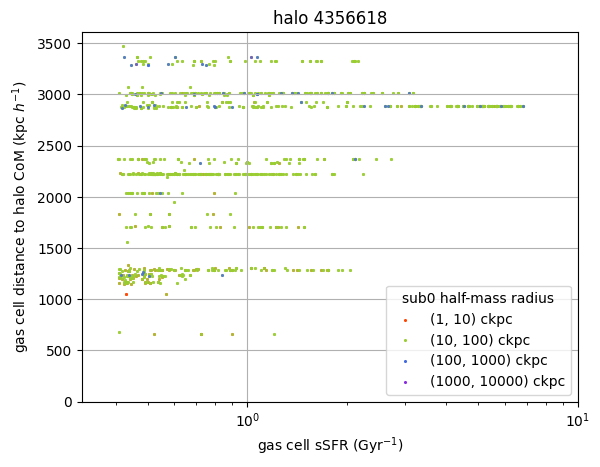

In [59]:
plt.title('halo ' + halo_id)

for i in np.arange(1, 5):
    select = (10**(i-1) < sub_rads) & (sub_rads < 10**i)
    plt.scatter(
        star_ssfr[select] * 1e9, 
        np.sqrt(raytrace.norm2(star_pos[select])), 
        s=5, alpha=0.8, lw=0, c=colors[i],
        label=f'({10.**(i-1):.0f}, {10**i:.0f}) ckpc'
    )
    # print(sub_lums)
plt.xlabel('gas cell sSFR (Gyr$^{-1}$)')
plt.gca().set_xscale('log')
# plt.gca().set_yscale('log')
# plt.ylim(1e1, 1e5)
plt.ylim(0)
plt.xlim(10**-0.5, 10**1)
plt.ylabel('gas cell distance to halo CoM (kpc $h^{-1}$)')
leg = plt.legend(title='sub0 half-mass radius', loc='lower right')
for lh in leg.legend_handles:
    lh.set_alpha(1)
plt.grid()
plt.savefig(f'outputs/plots/halo{halo_id}_dmssfr.png')
plt.show()


Text(0.5, 0, 'ssfr (/Gyr)')

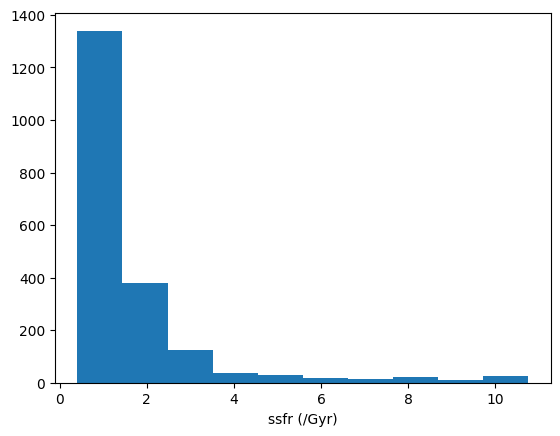

In [166]:
plt.hist(star_ssfr*1e9)
plt.xlabel('ssfr (/Gyr)')

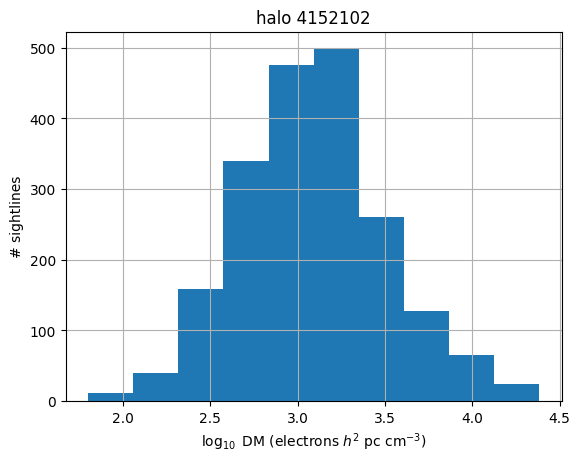

In [93]:
plt.title('halo ' + halo_id)
plt.hist(np.log10(dm * (cm_kpc**3) * 1000))
plt.grid()
plt.xlabel('$\log_{10}$ DM (electrons $h^2$ pc cm$^{-3}$)')
plt.ylabel('# sightlines')
plt.show()